<a href="https://colab.research.google.com/github/deliannepurgato/mvp-machine-learning-credit-risk/blob/main/PROJETO_MVP_DADOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Delianne Fernandes Purgato  
**Matrícula:** 4052026000610  
**Data:** 27/06/2026  
**Dataset:** Credit Risk Dataset

**Fonte:** https://www.kaggle.com/datasets/laotse/credit-risk-dataset

**Tipo de problema:** Classificação Supervisionada

---

## Introdução

A inadimplência representa um desafio relevante para instituições financeiras e demais organizações que operam com concessão de empréstimos e financiamentos. A capacidade de identificar padrões associados ao não cumprimento de obrigações financeiras pode contribuir para uma melhor compreensão dos fatores relacionados ao risco de inadimplência.

Neste projeto será realizada uma análise exploratória dos dados e o desenvolvimento de modelos de Machine Learning para prever o risco de inadimplência de clientes com base em características pessoais, financeiras e informações relacionadas ao histórico de crédito.

O trabalho seguirá as etapas de compreensão dos dados, preparação, modelagem, avaliação dos resultados e discussão das conclusões obtidas.


# 1. Definição do problema

## 1.1 Descrição do problema

Instituições financeiras concedem empréstimos diariamente para milhares de clientes. Entretanto, existe sempre o risco de que parte desses clientes não consiga honrar seus compromissos financeiros, gerando prejuízos para as organizações.

Neste contexto, torna-se importante identificar padrões que permitam estimar o risco de inadimplência dos clientes a partir de informações financeiras e de histórico de crédito.

O modelo desenvolvido neste MVP terá como objetivo apoiar a classificação de clientes quanto ao risco de inadimplência utilizando informações relacionadas à renda, idade, histórico de crédito, características do empréstimo e situação financeira dos indivíduos.

Os principais interessados nessa solução são bancos, financeiras, cooperativas de crédito e empresas que oferecem empréstimos e financiamentos.

Este problema é relevante porque a inadimplência impacta diretamente os resultados financeiros das instituições e a eficiência dos processos de concessão de crédito.

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
>O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o risco de inadimplência a partir de características financeiras, pessoais e de histórico de crédito dos clientes, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação  
**Justificativa:** O conjunto de dados possui uma variável-alvo denominada "loan_status", que representa a situação do empréstimo. O objetivo do modelo é prever se um cliente apresenta ou não risco de inadimplência com base em suas características, caracterizando um problema de classificação supervisionada.



## 1.4 Premissas, hipóteses e critérios de sucesso

Principais hipóteses em caso de MVP bem sucedido

**Hipóteses iniciais:**
1. clientes com menor renda apresentam maior probabilidade de inadimplência.
2. empréstimos que comprometem uma parcela elevada da renda tendem a apresentar maior risco de inadimplência.
3. clientes com histórico anterior de inadimplência possuem maior probabilidade de não cumprir novos compromissos financeiros.

**Critérios de sucesso:**
- Métrica principal: F1-Score
- Resultado mínimo esperado: obter desempenho superior ao modelo baseline e alcançar resultados consistentes na identificação de clientes inadimplentes.
- Restrição prática: o modelo deve possuir tempo de treinamento reduzido, ser reproduzível no Google Colab e permitir interpretação adequada dos resultados obtidos.

# 2. Ambiente, bibliotecas e reprodutibilidade

Este projeto foi desenvolvido utilizando o ambiente Google Colab, com execução em CPU padrão. O conjunto de dados utilizado possui mais de 32 mil registros, permitindo a aplicação de técnicas de Machine Learning supervisionado sem a necessidade de recursos computacionais avançados ou utilização de GPU.

Para garantir a reprodutibilidade dos resultados, foi definida uma semente aleatória fixa (SEED = 42). Dessa forma, etapas que envolvem aleatoriedade, como divisão dos dados em treino e teste, treinamento dos modelos e otimização de hiperparâmetros, podem ser reproduzidas de forma consistente em diferentes execuções.

As principais bibliotecas utilizadas neste trabalho incluem Pandas e NumPy para manipulação e processamento dos dados, Matplotlib e Seaborn para visualização gráfica, e Scikit-Learn para as etapas de pré-processamento, treinamento, otimização e avaliação dos modelos de Machine Learning. Também foi utilizada a biblioteca SciPy para apoio à busca de hiperparâmetros durante o processo de otimização.

O dataset é carregado diretamente a partir de um repositório público no GitHub, garantindo que qualquer usuário consiga reproduzir os resultados apresentados neste notebook sem necessidade de uploads manuais ou dependência de arquivos locais.

Todas as etapas do projeto foram implementadas de forma reprodutível dentro do próprio notebook, permitindo sua execução completa do início ao fim e a obtenção dos mesmos resultados apresentados neste MVP.




In [ ]:
# Bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca para medição de tempo de execução
import time

# Divisão dos dados em treino e teste
from sklearn.model_selection import train_test_split

# Tratamento de valores ausentes
from sklearn.impute import SimpleImputer

# Transformação de variáveis categóricas e padronização
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Construção de pipelines de pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de classificação
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Otimização de hiperparâmetros
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from scipy.stats import randint

# Métricas e avaliação dos modelos
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 2.2.2
NumPy: 2.0.2


## 2.1 Funções auxiliares

Foram criadas funções auxiliares para tornar o notebook mais organizado e evitar repetição de código ao longo do projeto.

A função 'resumo_dataset()' foi utilizada para exibir informações básicas do conjunto de dados, como quantidade de linhas, colunas e uma amostra dos registros. Já a função 'avaliar_modelo()' foi utilizada para calcular automaticamente as métricas Accuracy e F1-Score ponderado durante a comparação dos modelos de classificação.

Essas funções contribuíram para melhorar a legibilidade e a reutilização do código durante o desenvolvimento do MVP.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def resumo_dataset(df):
    print(f"Linhas: {df.shape[0]}")
    print(f"Colunas: {df.shape[1]}")
    display(df.head())

def avaliar_modelo(y_real, y_previsto):
    """
    Calcula métricas de desempenho para classificação.
    """

    return {
        "Accuracy": accuracy_score(y_real, y_previsto),
        "F1-Score": f1_score(y_real, y_previsto, average="weighted")
    }

# 3. Seleção e carga dos dados

## 3.1 Fonte dos Dados

O dataset utilizado neste projeto é um conjunto de dados público voltado para análise de risco de crédito e previsão de inadimplência.

O conjunto de dados contém informações relacionadas ao perfil dos clientes, características dos empréstimos concedidos e histórico financeiro, permitindo a construção de modelos de Machine Learning capazes de prever situações de inadimplência.

A escolha deste dataset ocorreu devido à sua relevância prática no mercado financeiro, à presença de uma variável-alvo adequada para problemas de classificação supervisionada e à quantidade expressiva de registros disponíveis para treinamento e avaliação dos modelos.

Para garantir a reprodutibilidade do projeto, os dados foram disponibilizados em um repositório público no GitHub e são carregados diretamente por URL durante a execução do notebook.

Os dados não possuem informações que permitam identificar diretamente indivíduos específicos, sendo adequados para fins acadêmicos e de pesquisa.


## 3.2 Carga dos dados

O conjunto de dados foi carregado diretamente de um repositório público no GitHub, garantindo a reprodutibilidade do projeto e dispensando uploads manuais durante a execução do notebook.


In [ ]:
# === Carga dos dados ===

import pandas as pd

url = "https://raw.githubusercontent.com/deliannepurgato/mvp-machine-learning-credit-risk/refs/heads/main/credit_risk_dataset.csv"

df = pd.read_csv(url)

print("Dimensões do dataset:", df.shape)

df.head()

Dimensões do dataset: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3.3 Visão geral do dataset

O conjunto de dados utilizado neste projeto possui **32.581 registros** e **12 atributos**, contendo informações relacionadas ao perfil dos clientes, características dos empréstimos concedidos e histórico financeiro.

Os atributos estão distribuídos entre variáveis numéricas e categóricas, permitindo a aplicação de técnicas de análise exploratória e classificação supervisionada.

Durante a análise inicial foram identificados valores ausentes nas colunas **person_emp_length** (895 registros) e **loan_int_rate** (3.116 registros). Esses valores serão tratados durante a etapa de preparação dos dados.

Também foram encontrados **165 registros duplicados**, que serão avaliados para verificar a necessidade de remoção antes da modelagem.

A variável-alvo do projeto é **loan_status**, responsável por indicar a situação do empréstimo. Trata-se de um problema de classificação binária, no qual:

> **0** representa clientes sem inadimplência;

> **1** representa clientes inadimplentes.

A distribuição da variável-alvo apresenta **25.473 registros da classe 0** e **7.108 registros da classe 1**, indicando um conjunto de dados moderadamente desbalanceado.

As variáveis disponíveis incluem informações relacionadas à idade, renda, tempo de emprego, finalidade do empréstimo, valor solicitado, taxa de juros, histórico de crédito e ocorrência anterior de inadimplência, características potencialmente relevantes para a previsão do risco de crédito.


In [ ]:
print("Linhas e colunas:")
print(df.shape)

Linhas e colunas:
(32581, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
print("Valores ausentes por coluna:")
display(df.isnull().sum().to_frame("ausentes"))

Valores ausentes por coluna:


,ausentes
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
print("Duplicatas:", df.duplicated().sum())


Duplicatas: 165


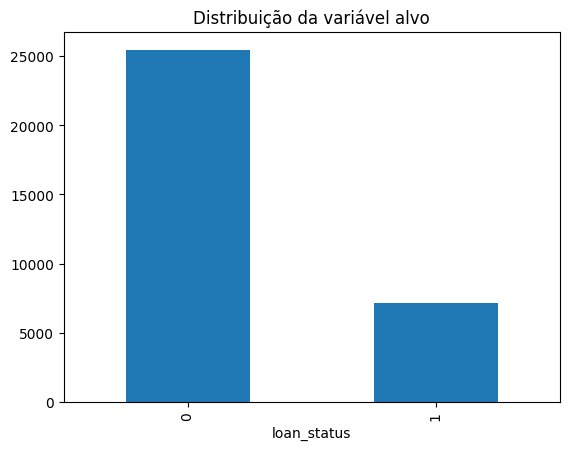

In [ ]:
df["loan_status"].value_counts().plot(kind="bar")
plt.title("Distribuição da variável alvo")
plt.show()

A tabela abaixo apresenta alguns registros aleatórios do conjunto de dados, permitindo visualizar exemplos das informações disponíveis sobre os clientes e empréstimos analisados.

In [ ]:
display(df.sample(5, random_state=SEED))

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
14668,24,28000,OWN,6.0,HOMEIMPROVEMENT,B,10000,10.37,0,0.36,N,2
24614,27,64000,RENT,0.0,PERSONAL,C,10000,15.27,0,0.16,Y,10
11096,26,72000,MORTGAGE,10.0,EDUCATION,D,16000,NaN,0,0.22,N,3
10424,23,27996,RENT,7.0,DEBTCONSOLIDATION,A,10000,NaN,1,0.36,N,2
26007,30,44500,RENT,2.0,MEDICAL,E,13000,16.32,1,0.29,N,6


## 3.4 Dicionário de dados

| Coluna                     | Tipo       | Descrição                                                 | Será usada no modelo? | Observações                                     |
| -------------------------- | ---------- | --------------------------------------------------------- | --------------------- | ----------------------------------------------- |
| person_age                 | Numérica   | Idade do cliente                                          | Sim                   | Pode influenciar o risco de crédito             |
| person_income              | Numérica   | Renda anual do cliente                                    | Sim                   | Indicador importante da capacidade de pagamento |
| person_home_ownership      | Categórica | Situação do imóvel do cliente                             | Sim                   | Pode indicar estabilidade financeira            |
| person_emp_length          | Numérica   | Tempo de emprego em anos                                  | Sim                   | Possui valores ausentes                         |
| loan_intent                | Categórica | Finalidade do empréstimo                                  | Sim                   | Pode influenciar o risco de inadimplência       |
| loan_grade                 | Categórica | Classificação de risco do empréstimo                      | Sim                   | Informação relevante para análise de crédito    |
| loan_amnt                  | Numérica   | Valor solicitado no empréstimo                            | Sim                   | Relacionado ao comprometimento financeiro       |
| loan_int_rate              | Numérica   | Taxa de juros do empréstimo                               | Sim                   | Possui valores ausentes                         |
| loan_status                | Alvo       | Situação do empréstimo (0 = adimplente, 1 = inadimplente) | Alvo                  | Variável a ser prevista                         |
| loan_percent_income        | Numérica   | Percentual da renda comprometido pelo empréstimo          | Sim                   | Potencial indicador de risco                    |
| cb_person_default_on_file  | Categórica | Histórico anterior de inadimplência                       | Sim                   | Pode influenciar fortemente a previsão          |
| cb_person_cred_hist_length | Numérica   | Tempo do histórico de crédito do cliente                  | Sim                   | Mede a experiência de crédito do cliente        |


Observa-se que o conjunto de dados possui atributos demográficos, financeiros e relacionados ao histórico de crédito dos clientes. A variável loan_status será utilizada como variável-alvo do modelo, enquanto os demais atributos serão empregados como variáveis preditoras durante o treinamento dos algoritmos de Machine Learning.



# 4. Análise exploratória dos dados

Nesta etapa é realizada a análise exploratória dos dados (EDA – Exploratory Data Analysis), com o objetivo de compreender melhor a distribuição das variáveis, identificar padrões relevantes e avaliar possíveis fatores relacionados à inadimplência. Os resultados obtidos nesta fase auxiliam na definição das estratégias de tratamento dos dados e na construção dos modelos de Machine Learning.


####**Distribuição da variável alvo**

A variável-alvo deste projeto é 'loan_status', responsável por indicar se o cliente apresentou ou não inadimplência. A análise de sua distribuição permite verificar o equilíbrio entre as classes e identificar possíveis desafios para o treinamento dos modelos de Machine Learning.

In [ ]:
# Definição da variável-alvo e do tipo de problema
TARGET = "loan_status"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target:


,contagem
loan_status,
0,25473
1,7108


,percentual
loan_status,
0,78.18
1,21.82


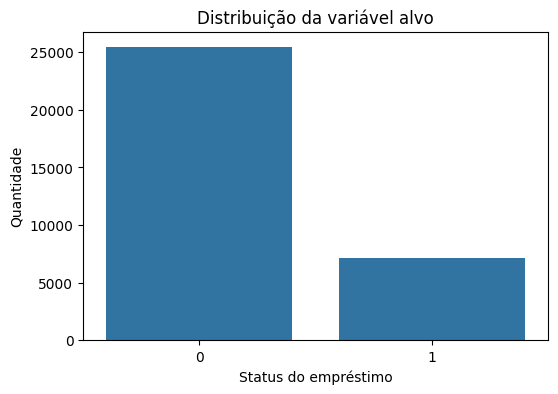

In [ ]:
# Visualização da distribuição da variável alvo (loan_status)
# Permite verificar o equilíbrio entre clientes inadimplentes e não inadimplentes

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="loan_status")

plt.title("Distribuição da variável alvo")
plt.xlabel("Status do empréstimo")
plt.ylabel("Quantidade")

plt.show()

Observa-se que a classe 0 (clientes sem inadimplência) representa 78,18% dos registros, enquanto a classe 1 (clientes inadimplentes) representa 21,82%. Esse comportamento indica um desbalanceamento moderado entre as classes, situação comum em problemas de risco de crédito.

Esse desbalanceamento deverá ser considerado durante a etapa de modelagem, pois alguns algoritmos podem apresentar tendência a favorecer a classe majoritária. Dessa forma, as métricas de avaliação serão analisadas com atenção para garantir que o modelo consiga identificar adequadamente os casos de inadimplência.


#### **Relação entre percentual da renda comprometida e inadimplência**

O percentual da renda comprometida pelo empréstimo pode representar um importante indicador de risco financeiro. Nesta etapa será analisada a relação entre essa variável e a ocorrência de inadimplência.

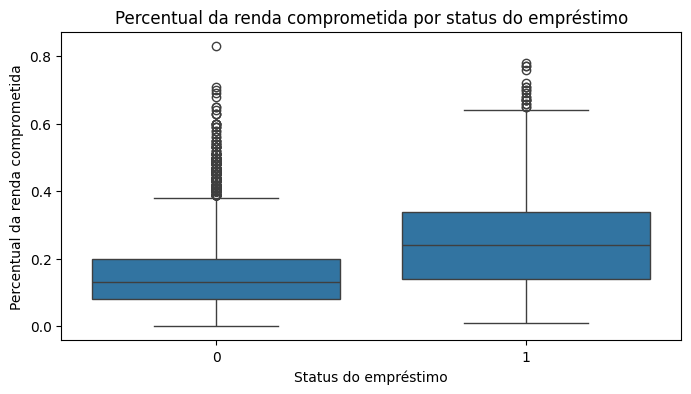

In [ ]:
# Comparação do percentual da renda comprometida entre clientes inadimplentes e não inadimplentes
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_percent_income"
)

plt.title("Percentual da renda comprometida por status do empréstimo")
plt.xlabel("Status do empréstimo")
plt.ylabel("Percentual da renda comprometida")

plt.show()

Observa-se que os clientes inadimplentes apresentam, em média, um percentual de renda comprometida pelo empréstimo superior ao dos clientes não inadimplentes. A mediana e a dispersão dos valores da classe 1 encontram-se em níveis mais elevados quando comparadas à classe 0.

Esse resultado sugere que o comprometimento excessivo da renda pode estar associado a um maior risco de inadimplência. Dessa forma, a variável loan_percent_income demonstra potencial relevância para os modelos de Machine Learning utilizados neste projeto.


####**Relação entre histórico de inadimplência e inadimplência atual**

O histórico de inadimplência é um dos fatores tradicionalmente utilizados em análises de crédito. Nesta etapa, será avaliada a relação entre a ocorrência de inadimplência anterior e a situação atual do empréstimo.

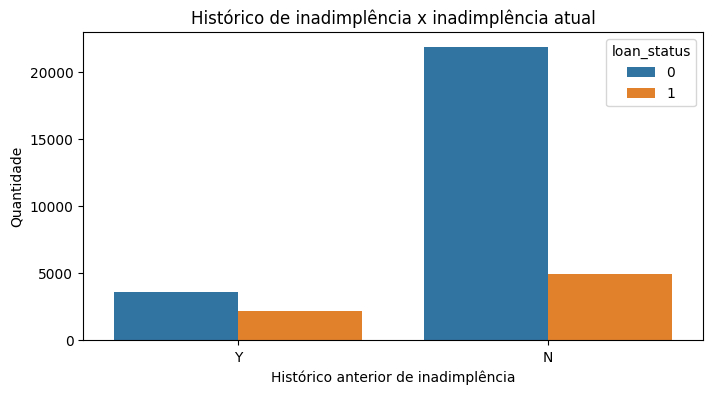

In [ ]:
# Avaliar a relação entre histórico de inadimplência e inadimplência atual
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="cb_person_default_on_file",
    hue="loan_status"
)

plt.title("Histórico de inadimplência x inadimplência atual")
plt.xlabel("Histórico anterior de inadimplência")
plt.ylabel("Quantidade")
plt.legend(title="loan_status")

plt.show()

## 4.1 Síntese da análise exploratória

A análise exploratória dos dados permitiu identificar características importantes do conjunto de dados e fatores potencialmente relacionados à inadimplência. Observou-se que a variável-alvo (loan_status) apresenta um desbalanceamento moderado, com aproximadamente 78% dos registros correspondendo a clientes sem inadimplência e 22% a clientes inadimplentes.

Também foram identificados valores ausentes nas variáveis person_emp_length e loan_int_rate, além da existência de registros duplicados que deverão ser tratados durante a etapa de pré-processamento.

Entre os padrões observados, destacou-se a relação entre o percentual da renda comprometida pelo empréstimo (loan_percent_income) e a inadimplência. Os resultados indicaram que clientes inadimplentes tendem a comprometer uma parcela maior de sua renda com empréstimos. Além disso, verificou-se que clientes com histórico anterior de inadimplência apresentam maior propensão à inadimplência atual.

Com base nesses achados, a etapa de preparação dos dados deverá incluir o tratamento de valores ausentes, a avaliação dos registros duplicados e a codificação das variáveis categóricas. Os resultados da análise exploratória também sugerem que variáveis relacionadas ao histórico de crédito e ao comprometimento da renda possuem potencial relevância para a construção dos modelos preditivos de classificação.



# 5. Preparação dos dados e divisão treino/teste


Para a construção dos modelos de Machine Learning, foi definida como variável-alvo a coluna 'loan_status', responsável por indicar a ocorrência ou não de inadimplência. As demais variáveis do conjunto de dados foram utilizadas como potenciais variáveis preditoras.

Não foi necessária a remoção de colunas de identificação, pois o dataset não possui atributos exclusivamente destinados à identificação dos registros. Também não foram identificadas colunas que pudessem causar vazamento de dados em relação à variável-alvo.

In [ ]:
# === Configuração do problema ===

TARGET = "loan_status"            # variável que queremos prever
PROBLEM_TYPE = "classificacao"    # problema de classificação

ID_COLUMNS = []                   # dataset não possui coluna de identificação
DATE_COLUMN = None                # não é série temporal
DROP_COLUMNS = []                 # nenhuma coluna removida nesta etapa

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [col for col in df.columns if col not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Variável alvo:", TARGET)
print("Quantidade de features:", len(features))
print("\nFeatures utilizadas:")
print(features)

Tipo de problema: classificacao
Variável alvo: loan_status
Quantidade de features: 11

Features utilizadas:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [ ]:
# === Divisão dos dados ===
# Separação entre variáveis preditoras (X) e variável alvo (y)

X = df[features].copy()
y = df[TARGET].copy()

# Divisão em treino e teste com estratificação
# A estratificação preserva a proporção de inadimplentes e não inadimplentes nos dois conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (26064, 11)
Teste: (6517, 11)


## 5.1 Justificativa da divisão

Foi utilizada a estratégia de holdout, na qual o conjunto de dados é dividido em duas partes: uma destinada ao treinamento dos modelos e outra reservada para avaliação final. Essa abordagem é adequada para este projeto devido ao tamanho do dataset, que possui 32.581 registros, permitindo a obtenção de amostras representativas tanto para treinamento quanto para teste.

A divisão adotada foi de 80% dos dados para treinamento (26.064 registros) e 20% para teste (6.517 registros). Essa proporção é amplamente utilizada em problemas de classificação supervisionada, pois fornece quantidade suficiente de exemplos para que os algoritmos aprendam os padrões dos dados, mantendo um conjunto independente para avaliação do desempenho.

Como a variável-alvo apresenta desbalanceamento moderado entre as classes, foi utilizada a estratificação ('stratify=y') durante a divisão dos dados. Dessa forma, a proporção de clientes inadimplentes e não inadimplentes foi preservada tanto no conjunto de treinamento quanto no conjunto de teste.

A validação cruzada não foi utilizada nesta etapa, uma vez que o objetivo inicial é estabelecer uma divisão consistente entre treino e teste. Essa técnica poderá ser empregada posteriormente durante a comparação e avaliação dos modelos.

Por fim, a divisão foi realizada antes do treinamento dos algoritmos, evitando que informações do conjunto de teste sejam utilizadas durante o aprendizado. Essa prática reduz o risco de vazamento de dados (data leakage) e permite uma avaliação mais confiável da capacidade de generalização dos modelos.



# 6. Pré-processamento e pipeline

Nesta etapa são realizadas as transformações necessárias para preparar os dados para o treinamento dos modelos de Machine Learning. Foram aplicadas técnicas de tratamento de valores ausentes, codificação de variáveis categóricas e padronização das variáveis numéricas.

As transformações foram organizadas em um pipeline reprodutível, garantindo que os ajustes sejam realizados apenas sobre os dados de treinamento, evitando vazamento de dados para o conjunto de teste.

In [ ]:
# Identificação automática das variáveis numéricas e categóricas

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Colunas categóricas: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## 6.1 Decisões de pré-processamento

Foram identificados valores ausentes nas variáveis 'person_emp_length' e 'loan_int_rate'. Para as variáveis numéricas foi utilizada imputação pela mediana, pois essa medida é menos sensível a valores extremos e preserva melhor a distribuição dos dados quando comparada à média.

As variáveis categóricas foram tratadas por meio da substituição dos valores ausentes pela categoria mais frequente (moda), estratégia amplamente utilizada quando não há informações adicionais para inferir os valores faltantes.

Foi aplicada padronização às variáveis numéricas utilizando o StandardScaler. Essa etapa foi adotada para reduzir diferenças de escala entre os atributos e favorecer o desempenho de algoritmos que são sensíveis à magnitude das variáveis.

As variáveis categóricas foram transformadas em representações numéricas por meio da técnica One-Hot Encoding, permitindo que os algoritmos de Machine Learning possam processar adequadamente essas informações.

Não foi necessária a remoção de colunas, uma vez que o conjunto de dados não possui atributos de identificação ou variáveis que possam causar vazamento de dados em relação à variável-alvo. Também não foram criadas novas variáveis nesta etapa, sendo utilizadas apenas as informações originalmente disponíveis no dataset.

Durante a análise exploratória foram identificados 165 registros duplicados. Para este MVP, optou-se por manter esses registros no conjunto de dados, pois não foi realizada uma análise específica para determinar se representam redundâncias indevidas ou observações legítimas do processo analisado. Essa limitação foi considerada na interpretação dos resultados.

Todas as transformações foram organizadas em um pipeline, garantindo reprodutibilidade e evitando que informações do conjunto de teste influenciem o treinamento dos modelos.



# 7. Baseline e modelos candidatos

Foi definido um modelo baseline simples com DummyClassifier, que prevê sempre a classe majoritária. Além disso, foram selecionados quatro modelos candidatos de classificação: Regressão Logística, Random Forest, Árvore de Decisão e KNN. Esses modelos foram escolhidos por representarem abordagens diferentes para o problema de classificação de inadimplência.


In [ ]:
# === Definição de baseline e modelos candidatos ===

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=500, random_state=SEED))
    ]),

    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ]),

    "DecisionTree": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=SEED))
    ]),

    "KNN": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier())
    ])
}

print("Modelo baseline: DummyClassifier")
print("Modelos candidatos:", list(candidates.keys()))

Modelo baseline: DummyClassifier
Modelos candidatos: ['LogisticRegression', 'RandomForest', 'DecisionTree', 'KNN']


## 7.1 Justificativa dos modelos

O modelo baseline escolhido foi o DummyClassifier, configurado para prever sempre a classe mais frequente. Essa abordagem é coerente com o objetivo do projeto, pois fornece uma referência mínima de desempenho, permitindo verificar se os modelos de Machine Learning realmente conseguem aprender padrões relevantes nos dados.

Como modelos candidatos foram selecionados Logistic Regression, Random Forest, Decision Tree e KNN. Esses algoritmos são amplamente utilizados em problemas de classificação e apresentam características distintas de aprendizado, permitindo uma comparação mais abrangente dos resultados.

A Regressão Logística foi escolhida por ser um modelo simples, interpretável e frequentemente utilizado em problemas de risco de crédito. A Árvore de Decisão permite identificar regras de classificação de forma intuitiva, enquanto o Random Forest busca melhorar a capacidade preditiva por meio da combinação de múltiplas árvores. Já o KNN foi incluído por representar uma abordagem baseada em similaridade entre observações.

Os modelos escolhidos são adequados ao tamanho do conjunto de dados, que possui mais de 32 mil registros. Além disso, alguns algoritmos, como Logistic Regression e KNN, são sensíveis à escala das variáveis, justificando a utilização da padronização realizada na etapa de pré-processamento. Da mesma forma, todos os modelos exigem que as variáveis categóricas sejam convertidas para formato numérico, o que foi realizado por meio do One-Hot Encoding.

Em relação ao custo computacional, todos os modelos selecionados apresentam tempo de treinamento compatível com o porte do dataset utilizado. Além disso, a presença de modelos mais interpretáveis, como Logistic Regression e Decision Tree, possibilita comparar desempenho preditivo e facilidade de interpretação dos resultados.



# 8. Treinamento e avaliação inicial

Nesta etapa foram treinados o modelo baseline e os modelos candidatos definidos anteriormente. O objetivo é realizar uma avaliação inicial do desempenho de cada algoritmo na tarefa de previsão de inadimplência.

Para a comparação dos modelos foram utilizadas as métricas Accuracy e F1-Score. Além disso, foi registrado o tempo de treinamento de cada modelo, permitindo avaliar não apenas a capacidade preditiva, mas também o custo computacional de cada abordagem.



In [ ]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)

results["baseline"] = avaliar_modelo(y_test, y_pred)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    results[name] = avaliar_modelo(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

pd.DataFrame(results).T

,Accuracy,F1-Score,train_time_s
baseline,0.781801,0.686062,0.165
LogisticRegression,0.867117,0.859259,0.881
RandomForest,0.933712,0.929916,10.985
DecisionTree,0.886604,0.887799,0.549
KNN,0.886911,0.879988,0.160


## 8.1 Análise dos resultados iniciais

Os resultados demonstram que todos os modelos candidatos superaram o baseline, indicando que os algoritmos foram capazes de aprender padrões relevantes relacionados à inadimplência. Enquanto o baseline obteve Accuracy de 78,18% e F1-Score de 68,61%, todos os demais modelos apresentaram desempenho superior.

As métricas Accuracy e F1-Score mostraram-se adequadas para uma avaliação inicial do problema. Como o conjunto de dados apresenta desbalanceamento entre as classes, o F1-Score é especialmente importante por considerar simultaneamente precisão e revocação, fornecendo uma visão mais completa do desempenho dos modelos.

Não foram observados indícios claros de underfitting, uma vez que todos os modelos candidatos obtiveram desempenho significativamente superior ao baseline. O Random Forest apresentou os melhores resultados, alcançando Accuracy de 93,37% e F1-Score de 92,99%.

O tempo de treinamento foi aceitável para todos os modelos avaliados. Embora o Random Forest tenha apresentado o maior tempo de processamento, seu desempenho superior justifica esse custo computacional adicional.

Os resultados obtidos fazem sentido quando comparados aos achados da análise exploratória dos dados. Durante a EDA foram identificadas relações entre inadimplência, histórico de crédito e comprometimento da renda, fatores que provavelmente contribuíram para a capacidade dos modelos em diferenciar clientes inadimplentes e não inadimplentes.


# 9. Validação e otimização de hiperparâmetros

Após a avaliação inicial dos modelos, foi selecionado o Random Forest para a etapa de otimização de hiperparâmetros, pois apresentou o melhor desempenho entre os modelos candidatos.

Foi utilizada uma busca aleatória de hiperparâmetros por meio do RandomizedSearchCV, permitindo testar diferentes combinações de parâmetros do modelo com baixo custo computacional. A avaliação foi realizada utilizando validação cruzada estratificada, buscando maximizar o F1-Score ponderado, métrica considerada adequada para este problema devido ao desbalanceamento existente entre as classes.


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.9285685722812463
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


## 9.1 Discussão da otimização

A etapa de otimização permitiu identificar uma configuração de hiperparâmetros com bom desempenho para o modelo Random Forest. Durante a validação cruzada, a melhor combinação encontrada alcançou F1-Score médio de 0,9286, demonstrando elevada capacidade de classificação.

A busca foi propositalmente limitada a cinco combinações aleatórias de hiperparâmetros (n_iter = 5), conforme definido no RandomizedSearchCV. Essa escolha foi realizada para manter o custo computacional compatível com os objetivos do MVP, permitindo explorar diferentes configurações sem aumentar excessivamente o tempo de processamento.

Os hiperparâmetros selecionados fazem sentido para o problema estudado. A utilização de 121 árvores fornece diversidade suficiente para o conjunto Random Forest, enquanto a profundidade máxima de 16 níveis permite capturar relações mais complexas entre as variáveis. Já o parâmetro min_samples_split igual a 4 contribui para reduzir divisões excessivamente específicas, auxiliando no controle do sobreajuste.

Como a busca realizada foi reduzida e exploratória, não é possível afirmar que a melhor configuração global foi encontrada. Caso houvesse mais tempo disponível para o desenvolvimento do projeto, seria interessante ampliar o número de combinações testadas e avaliar outros hiperparâmetros do Random Forest, buscando possíveis ganhos adicionais de desempenho.



# 10. Avaliação final no conjunto de teste

Após a etapa de otimização de hiperparâmetros, o melhor modelo foi selecionado para avaliação final no conjunto de teste. Essa avaliação foi realizada utilizando dados que não participaram do treinamento nem do processo de otimização, permitindo uma estimativa mais confiável da capacidade de generalização do modelo.

Além das métricas de classificação, foi analisada a matriz de confusão para identificar os principais tipos de erro cometidos pelo modelo e avaliar seu comportamento na identificação de clientes inadimplentes e não inadimplentes.



Modelo final: Random Forest otimizado
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5095
           1       0.98      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.94      0.93      0.93      6517



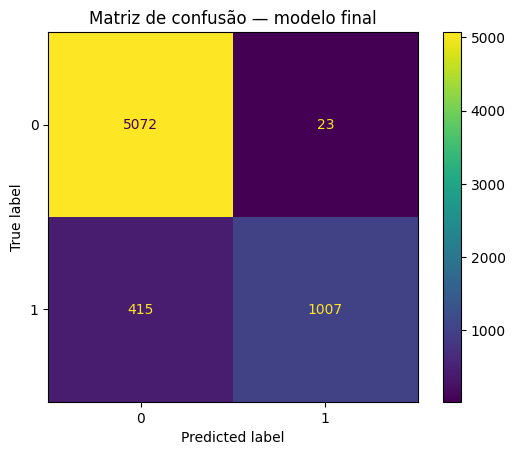

In [ ]:
# === Avaliação final ===

final_model = search.best_estimator_

print("Modelo final: Random Forest otimizado")

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("Matriz de confusão — modelo final")
plt.show()

## 10.1 Análise de erros e limitações

O modelo final apresentou Accuracy de 93% e F1-Score ponderado de 93%, demonstrando excelente desempenho na identificação de clientes inadimplentes e não inadimplentes. Em comparação ao baseline, que obteve Accuracy de aproximadamente 78%, houve uma melhoria significativa na capacidade preditiva do modelo.

A análise da matriz de confusão mostra que o modelo classificou corretamente 5.072 clientes não inadimplentes e 1.007 clientes inadimplentes. Os principais erros ocorreram nos casos em que clientes inadimplentes foram classificados como não inadimplentes, totalizando 415 ocorrências. Já os falsos positivos foram pouco frequentes, com apenas 23 casos.

Não foram observados sinais evidentes de underfitting, pois o modelo apresentou desempenho elevado tanto na validação quanto no conjunto de teste. Entretanto, uma avaliação mais aprofundada seria necessária para descartar completamente a possibilidade de overfitting, utilizando conjuntos de dados externos ou validações adicionais.

A métrica F1-Score mostrou-se adequada para este problema, pois considera simultaneamente precisão e revocação, sendo especialmente útil em cenários com classes desbalanceadas. Os resultados indicam que o modelo consegue identificar a maior parte dos casos de inadimplência mantendo uma taxa reduzida de classificações incorretas.

Como limitações, destaca-se que o modelo foi treinado com dados históricos e pode não refletir mudanças futuras no comportamento dos clientes ou nas condições econômicas. Além disso, o modelo deve ser utilizado como ferramenta de apoio à análise de risco, não devendo ser empregado como único critério para tomada de decisão.



# 11. Comparação final dos modelos

| Modelo                  | Métrica principal (F1-Score) | Accuracy | Tempo aproximado de treino (s) | Observações                                                                                                                                                          |
| ----------------------- | ---------------------------- | -------- | ------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Baseline                | 0,686                        | 0,782    | 0,069               | Utiliza apenas a classe majoritária como previsão. Serve como referência para comparação.                                                                            |
| Logistic Regression     | 0,859                        | 0,867    | 0,540               | Modelo simples e interpretável. Superou o baseline com boa margem.                                                                                                   |
| Random Forest           | 0,930                        | 0,934    | 9,030               | Melhor desempenho entre os modelos avaliados. Capturou relações complexas entre as variáveis.                                                                        |
| Decision Tree           | 0,888                        | 0,887    | 0,416               | Apresentou bom desempenho, porém inferior ao Random Forest.                                                                                                          |
| KNN                     | 0,880                        | 0,887    | 0,108               | Resultado satisfatório, mas abaixo do Random Forest.                                                                                                                 |
| Random Forest Otimizado | 0,929*                       | 0,933**  | -                   | Melhor configuração obtida por otimização de hiperparâmetros (121 árvores, profundidade máxima 16 e min_samples_split = 4). Modelo selecionado para avaliação final. |

* F1-Score médio obtido durante a validação cruzada da etapa de otimização.

* Accuracy observada na avaliação final do conjunto de teste.

A comparação dos modelos demonstra que todos os algoritmos candidatos superaram significativamente o baseline. O Random Forest apresentou o melhor desempenho na avaliação inicial e, após a otimização de hiperparâmetros, manteve desempenho elevado, sendo selecionado como modelo final do projeto.

Além de alcançar as melhores métricas de classificação, o Random Forest demonstrou boa capacidade de generalização e manteve tempo de treinamento compatível com os objetivos do MVP. Por esse motivo, foi considerado o modelo mais adequado para a tarefa de identificação de risco de inadimplência.




# 12. Boas práticas e rastreabilidade

Durante o desenvolvimento do MVP foram registradas as principais decisões relacionadas ao pré-processamento, treinamento, avaliação e otimização dos modelos. Esse registro facilita a reprodutibilidade dos experimentos e permite compreender os impactos de cada escolha realizada ao longo do projeto.

| Decisão                                              | Justificativa                                                    | Impacto esperado                                                   |
| ---------------------------------------------------- | ---------------------------------------------------------------- | ------------------------------------------------------------------ |
| Utilizar seed 42                                     | Garantir reprodutibilidade dos resultados                        | Permitir repetir os experimentos obtendo os mesmos resultados      |
| Utilizar F1-Score como métrica principal             | O dataset apresenta desbalanceamento entre as classes            | Avaliar melhor o desempenho na identificação da classe minoritária |
| Utilizar divisão holdout 80/20 com estratificação    | Preservar a proporção das classes em treino e teste              | Avaliação mais confiável do modelo                                 |
| Imputar valores ausentes com mediana e moda          | Existência de valores nulos em variáveis numéricas e categóricas | Evitar perda de registros e permitir treinamento dos modelos       |
| Aplicar padronização nas variáveis numéricas         | Algumas variáveis possuem escalas diferentes                     | Melhorar o desempenho de algoritmos sensíveis à escala             |
| Aplicar One-Hot Encoding nas variáveis categóricas   | Os modelos exigem entradas numéricas                             | Permitir utilização das variáveis categóricas                      |
| Testar Logistic Regression                           | Servir como modelo linear de referência                          | Comparar desempenho com modelos mais complexos                     |
| Testar Decision Tree                                 | Capturar relações não lineares entre as variáveis                | Melhorar a capacidade de classificação                             |
| Testar KNN                                           | Avaliar uma abordagem baseada em proximidade                     | Comparar diferentes estratégias de classificação                   |
| Testar Random Forest                                 | Combinar múltiplas árvores de decisão                            | Obter melhor capacidade preditiva                                  |
| Utilizar RandomizedSearchCV                          | Realizar otimização simples de hiperparâmetros                   | Melhorar o desempenho do modelo sem elevado custo computacional    |
| Limitar a busca a n_iter = 5                         | Reduzir tempo de processamento                                   | Tornar a otimização compatível com o escopo do MVP                 |
| Selecionar Random Forest otimizado como modelo final | Apresentou os melhores resultados de classificação               | Maximizar a capacidade de previsão de inadimplência                |
| Descartar o uso exclusivo do baseline                | Desempenho insuficiente para o problema                          | Utilizar modelos capazes de aprender padrões dos dados             |


# 13. Conclusão

O objetivo deste trabalho foi desenvolver um modelo de Machine Learning capaz de identificar o risco de inadimplência de clientes com base em características financeiras e de histórico de crédito. Para isso, foram realizadas etapas de análise exploratória, preparação dos dados, treinamento de modelos, otimização de hiperparâmetros e avaliação final.

Os resultados demonstraram que os modelos de classificação foram capazes de identificar padrões relevantes associados à inadimplência. Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho e foi selecionado como solução final do projeto. Em comparação ao baseline, o modelo escolhido apresentou uma melhoria significativa na capacidade de classificação, evidenciando que foi capaz de aprender relações relevantes presentes nos dados.

Durante o desenvolvimento do MVP, foi possível observar a importância do tratamento adequado dos dados, da escolha das métricas de avaliação e da comparação entre diferentes algoritmos. A análise exploratória também permitiu identificar fatores potencialmente relacionados à inadimplência, como o comprometimento da renda e o histórico de crédito dos clientes.

Apesar dos resultados satisfatórios, o projeto apresenta algumas limitações. O modelo foi desenvolvido com base em dados históricos e, portanto, seu desempenho pode variar quando aplicado a cenários futuros ou a populações com características diferentes das observadas no conjunto de dados utilizado. Além disso, o modelo deve ser interpretado como uma ferramenta de apoio à análise de risco, não substituindo avaliações especializadas ou outros critérios de negócio.

Como trabalhos futuros, poderiam ser testados novos algoritmos, técnicas mais avançadas de otimização de hiperparâmetros e conjuntos de dados adicionais. Também seria interessante avaliar o comportamento do modelo em diferentes cenários econômicos e incorporar novas variáveis que possam contribuir para uma previsão ainda mais precisa do risco de inadimplência.

De forma geral, os resultados obtidos indicam que a abordagem proposta foi adequada para o problema estudado, demonstrando o potencial da utilização de técnicas de Machine Learning na identificação de padrões associados à inadimplência e no apoio à tomada de decisão baseada em dados.
